In [16]:
import os
import sys
import random
import copy
import itertools
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

CMA_ES_SEARCH_BEST_ESN_MODEL = False

# Load Dataset

In [17]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}

    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 2)
        if len(parts) < 2:
            continue

        terrain, sensor = f"{parts[0]}_{parts[1]}", parts[2]

        if terrain not in reconstructed:
            reconstructed[terrain] = {}

        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]

    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

In [18]:
print(dataset.keys())
print(dataset['solid_ground'].keys())

In [19]:
name_joints = ['FR_J1', 'FR_J2', 'FR_J3', 'FR_J4',
 'BR_J1', 'BR_J2', 'BR_J3', 'BR_J4',
 'FL_J1', 'FL_J2', 'FL_J3', 'FL_J4',
 'BL_J1', 'BL_J2', 'BL_J3', 'BL_J4']

name_legs = ['FR', 'BR', 'FL', 'BL']

# Front/back leg-group split for the sub-reservoir ESN.
# Front legs (FR, FL) contact new terrain first during forward walking,
# so a front-group model should flip its prediction before the
# back-group model. If a leg is lost/damaged, the OTHER group's
# reservoir is untouched, unlike a single combined 4-leg reservoir.
FRONT_LEGS = ['FR', 'FL']
BACK_LEGS = ['BR', 'BL']

# Prepare Dataset

In [20]:
def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
    """
    Splits the gait cycle dataset into training and testing sets.
    Safely handles sensors with mismatched cycle counts.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue

        min_cycles = min(sensor_counts)

        indices = list(range(min_cycles))
        random.shuffle(indices)

        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]

        train_set[terrain] = {}
        test_set[terrain] = {}

        for sensor in dataset[terrain].keys():
            all_cycles = dataset[terrain][sensor]
            train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
            test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]

        print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
              f"({len(train_indices)} train, {len(test_indices)} test)")

    return train_set, test_set

# --- Execution ---
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.3)

In [21]:
def _leg_group_column_mask_and_labels(n_columns, legs_to_keep):
    """
    Builds a boolean column mask + per-selected-column leg label for a
    sensor array, keeping only columns belonging to `legs_to_keep`.

    Joint-level sensors have 16 columns ordered per `name_joints`
    (FR_J1..4, BR_J1..4, FL_J1..4, BL_J1..4) - 4 columns per leg.
    Leg-level sensors (leg_stiffness, leg_damping, leg_torque_feedforward,
    foot_force) have 4 columns ordered per `name_legs` - 1 column per leg.

    Sensor arrays in walking_terrain_datasets.npz actually carry ONE
    extra trailing column beyond that (5 for leg-level, 17 for
    joint-level) - a shared, monotonically increasing within-cycle
    time/phase value appended after the leg/joint columns (same value
    regardless of sensor). It doesn't belong to any single leg, so it's
    kept for BOTH front and back groups (labeled 'TIME'), matching how
    the un-split flatten_datasets/ESN_RR_Classification pipeline already
    treats it - only the very last column of the full concatenated
    feature matrix gets dropped by `ignore_time_column=True`.
    """
    if n_columns in (len(name_joints), len(name_joints) + 1):
        names, leg_of = name_joints, (lambda n: n[:2])
    elif n_columns in (len(name_legs), len(name_legs) + 1):
        names, leg_of = name_legs, (lambda n: n)
    else:
        raise ValueError(
            f"Unrecognized sensor column count {n_columns}: expected "
            f"{len(name_joints)}/{len(name_joints) + 1} (joint-level) or "
            f"{len(name_legs)}/{len(name_legs) + 1} (leg-level)."
        )

    has_time_column = n_columns == len(names) + 1

    mask = np.array([leg_of(n) in legs_to_keep for n in names] + ([True] if has_time_column else []))
    labels = [leg_of(n) for n in names if leg_of(n) in legs_to_keep] + (['TIME'] if has_time_column else [])
    return mask, labels


def flatten_datasets_leg_group(dataset_dict, terrain_to_id_map, sensor_order, legs_to_keep):
    """
    Same as flatten_datasets, but keeps only the columns belonging to
    `legs_to_keep` (e.g. FRONT_LEGS or BACK_LEGS) for every sensor.
    Also returns `column_leg_labels`: which leg each output column
    belongs to, needed for leg-dropout augmentation and leg-loss tests.
    """
    X_formatted = []
    y_formatted = []
    column_leg_labels = None  # identical for every cycle, computed once

    for terrain, sensors_data in dataset_dict.items():
        if terrain not in terrain_to_id_map:
            continue

        label = terrain_to_id_map[terrain]
        n_cycles = len(sensors_data[sensor_order[0]])

        for i in range(n_cycles):
            cycle_columns = []
            cycle_labels = []
            for sensor_name in sensor_order:
                sensor_array = np.array(sensors_data[sensor_name][i])

                if len(sensor_array.shape) == 1:
                    sensor_array = sensor_array.reshape(-1, 1)

                mask, labels = _leg_group_column_mask_and_labels(sensor_array.shape[1], legs_to_keep)
                cycle_columns.append(sensor_array[:, mask])
                cycle_labels.extend(labels)

            full_gait_matrix = np.hstack(cycle_columns)

            X_formatted.append(full_gait_matrix)
            y_formatted.append(label)
            column_leg_labels = cycle_labels

    return X_formatted, np.array(y_formatted), column_leg_labels

In [22]:
def simulate_sensor_noise_ptp(X_test, noise_level=0.10, seed=42):
    """
    Simulates noise scaled to the Peak-to-Peak (Full-Scale) range of the sensor.
    """
    np.random.seed(seed)
    X_noisy = []

    for cycle in X_test:
        noisy_cycle = cycle.copy()

        feature_scales = np.ptp(noisy_cycle, axis=0)
        feature_scales[feature_scales == 0] = 1.0

        standard_normal_noise = np.random.normal(loc=0.0, scale=1.0, size=noisy_cycle.shape)
        scaled_noise = standard_normal_noise * (noise_level * feature_scales)

        noisy_cycle += scaled_noise
        X_noisy.append(noisy_cycle)

    return X_noisy

In [23]:
def simulate_leg_dropout(X, column_leg_labels, legs_in_group, dropout_prob=0.3, seed=42):
    """
    Randomly zeroes out ALL columns belonging to ONE of the two legs in a
    leg-group's feature set, for a fraction of cycles, so each
    sub-reservoir learns to still predict terrain when one of its own
    two legs goes offline ("cutting the leg"). Cross-group fault
    isolation (the OTHER group being unaffected) is free from the
    architecture; this augmentation is what makes a group itself
    robust to losing one of its two legs.
    """
    assert len(legs_in_group) == 2, "simulate_leg_dropout expects a 2-leg group"

    column_leg_labels = np.array(column_leg_labels)
    leg_masks = {leg: (column_leg_labels == leg) for leg in legs_in_group}

    rng = np.random.default_rng(seed)
    X_dropout = []

    for cycle in X:
        cycle = cycle.copy()
        if rng.random() < dropout_prob:
            leg_to_drop = legs_in_group[rng.integers(0, 2)]
            cycle[:, leg_masks[leg_to_drop]] = 0.0
        X_dropout.append(cycle)

    return X_dropout

## Training (CMA-ES Search)

In [24]:
import optuna
from optuna.samplers import CmaEsSampler
from models.model_1_esn_rr.env_pred import ESN_RR_Classification

# Suppress Optuna's default print spam to keep your terminal output clean
optuna.logging.set_verbosity(optuna.logging.WARNING)

TERRAIN_LABELS = {
    'solid_ground'      : 0,
    'soft_ground'       : 1,
    'slippery_ground'   : 2,
    'rough_ground'      : 3,
    'muddy_ground'      : 4,
    'water_surface'     : 5
}

SENSOR_CONFIGURATIONS = [
    ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward', 'foot_force', 'joint_angle_fb', 'joint_velocity_fb'],
]

CMA_ES_SEARCH_BEST_ESN_MODEL = True
N_TRIALS_PER_CONFIG = 1  # Smoke test: just confirm the leg-group pipeline runs end-to-end.


def run_cma_es_search_for_group(group_name, legs_to_keep, save_dir="trained_models_w_noise"):
    """
    Runs an Optuna CMA-ES hyperparameter search for one leg group (front
    or back), mirroring train_models_esn_rr.ipynb's CMA-ES cell, but
    built from leg-group-only features via flatten_datasets_leg_group.
    """
    print(f"\n{'#'*60}\n LEG GROUP: {group_name.upper()} ({legs_to_keep})\n{'#'*60}")
    os.makedirs(save_dir, exist_ok=True)

    for config_idx, current_sensor_keys in enumerate(SENSOR_CONFIGURATIONS):
        config_name = f"config_{config_idx + 1}"

        print(f"\n🚀 STARTING CMA-ES SEARCH [{group_name}/{config_name}]")
        print(f"📡 Sensors: {current_sensor_keys}")

        X_train_clean, y_train_clean, col_labels = flatten_datasets_leg_group(
            train_data, TERRAIN_LABELS, current_sensor_keys, legs_to_keep)
        X_test_clean, y_test_clean, _ = flatten_datasets_leg_group(
            test_data, TERRAIN_LABELS, current_sensor_keys, legs_to_keep)

        if len(X_test_clean) > 0 and len(X_train_clean) > 0:
            test_sample = X_test_clean[0]
            leak_found = any(np.array_equal(test_sample, train_sample) for train_sample in X_train_clean)
            print("✅ Data split is clean!" if not leak_found else "🚨 WARNING: DATA LEAKAGE DETECTED!")

        print("🧬 Generating Augmented Training and Evaluation Sets...")
        X_train_noisy = simulate_sensor_noise_ptp(X_train_clean, noise_level=0.10, seed=42)
        X_train_dropout = simulate_leg_dropout(X_train_clean, col_labels, legs_to_keep, dropout_prob=0.3, seed=43)

        X_train_aug = list(X_train_clean) + list(X_train_noisy) + list(X_train_dropout)
        y_train_aug = np.concatenate([np.array(y_train_clean)] * 3)

        X_test_noisy = simulate_sensor_noise_ptp(X_test_clean, noise_level=0.15, seed=99)
        X_test_eval = list(X_test_clean) + list(X_test_noisy)
        y_test_eval = np.concatenate([np.array(y_test_clean), np.array(y_test_clean)])

        print(f"Total Augmented Training Cycles: {len(X_train_aug)}")
        print(f"Total Robust Evaluation Cycles: {len(X_test_eval)}")
        print(f"Input Matrix Shape: {X_train_aug[0].shape}\n")

        def objective(trial):
            n_res = trial.suggest_int('n_reservoir', 500, 5000)
            leak_rate = trial.suggest_float('leak_rate', 0.1, 0.9)
            spectral_radius = trial.suggest_float('spectral_radius', 0.7, 1.25)
            lambda_reg = trial.suggest_float('lambda_reg', 1e-4, 1.0, log=True)

            model = ESN_RR_Classification(
                n_reservoir=n_res,
                leak_rate=leak_rate,
                spectral_radius=spectral_radius,
                lambda_reg=lambda_reg,
                ignore_time_column=True,
                output_steps='mean',
                random_state=42
            )

            try:
                sys.stdout = open(os.devnull, 'w')
                model.fit(X_train_aug, y_train_aug)
                sys.stdout = sys.__stdout__

                correct = 0
                for j in range(len(X_test_eval)):
                    predicted_class, _ = model.predict(X_test_eval[j])
                    if predicted_class == y_test_eval[j]:
                        correct += 1

                accuracy = (correct / len(X_test_eval)) * 100.0
            except Exception as e:
                sys.stdout = sys.__stdout__
                return 10.0

            return accuracy

        sampler = CmaEsSampler(seed=42, restart_strategy="ipop", inc_popsize=2)
        study = optuna.create_study(direction="maximize", sampler=sampler)

        print(f"Running CMA-ES for {N_TRIALS_PER_CONFIG} generations...")
        study.optimize(objective, n_trials=N_TRIALS_PER_CONFIG, show_progress_bar=True)

        best_params = study.best_params
        best_accuracy = study.best_value

        print(f"\n🏆 BEST MODEL FOUND FOR: {group_name}/{config_name.upper()}")
        print(f"Robust Accuracy: {best_accuracy:.2f}%")
        for k, v in best_params.items():
            print(f" - {k}: {v}")

        final_model = ESN_RR_Classification(
            n_reservoir=best_params['n_reservoir'],
            leak_rate=best_params['leak_rate'],
            spectral_radius=best_params['spectral_radius'],
            lambda_reg=best_params['lambda_reg'],
            ignore_time_column=True,
            output_steps='mean',
            random_state=42
        )
        final_model.fit(X_train_aug, y_train_aug)

        filename = f"{save_dir}/model_5_esn_leg_group_{group_name}_{config_name}_w_cma_es.pt"
        final_model.save_model(filename)

    print(f"\n✅ {group_name.upper()} GROUP: ALL CONFIGURATIONS TESTED AND SAVED!")


if CMA_ES_SEARCH_BEST_ESN_MODEL:
    run_cma_es_search_for_group('front', FRONT_LEGS)
    run_cma_es_search_for_group('back', BACK_LEGS)

/home/runj/.local/lib/python3.10/site-packages/optuna/samplers/_cmaes.py:293: FutureWarning: `restart_strategy` has been deprecated in v4.4.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.4.0. From v4.4.0 onward, `restart_strategy` automatically falls back to `None`. `restart_strategy` will be supported in OptunaHub.
  optuna_warn(


  0%|          | 0/1 [00:00<?, ?it/s]

/home/runj/.local/lib/python3.10/site-packages/optuna/samplers/_cmaes.py:293: FutureWarning: `restart_strategy` has been deprecated in v4.4.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.4.0. From v4.4.0 onward, `restart_strategy` automatically falls back to `None`. `restart_strategy` will be supported in OptunaHub.
  optuna_warn(


  0%|          | 0/1 [00:00<?, ?it/s]

# Test

In [25]:
print("Booting up ESN Leg-Group Controller...")

terrains = list(dataset.keys())
ID_TO_TERRAIN = {i: name for i, name in enumerate(terrains)}
TERRAIN_LABELS = {name: i for i, name in enumerate(terrains)}

TEST_SENSOR_CONFIG = SENSOR_CONFIGURATIONS[0]
TEST_CONFIG_NAME = "config_1"

front_model = ESN_RR_Classification()
front_model.load_model(f"trained_models_w_noise/model_5_esn_leg_group_front_{TEST_CONFIG_NAME}_w_cma_es.pt")

back_model = ESN_RR_Classification()
back_model.load_model(f"trained_models_w_noise/model_5_esn_leg_group_back_{TEST_CONFIG_NAME}_w_cma_es.pt")

X_test_front, y_test, front_col_labels = flatten_datasets_leg_group(test_data, TERRAIN_LABELS, TEST_SENSOR_CONFIG, FRONT_LEGS)
X_test_back, _, back_col_labels = flatten_datasets_leg_group(test_data, TERRAIN_LABELS, TEST_SENSOR_CONFIG, BACK_LEGS)

y_pred_front = np.array([front_model.predict(x)[0] for x in X_test_front])
y_pred_back = np.array([back_model.predict(x)[0] for x in X_test_back])

acc_front = (y_pred_front == y_test).mean() * 100
acc_back = (y_pred_back == y_test).mean() * 100
print(f"Front-group Test Accuracy: {acc_front:.2f}%")
print(f"Back-group Test Accuracy:  {acc_back:.2f}%")

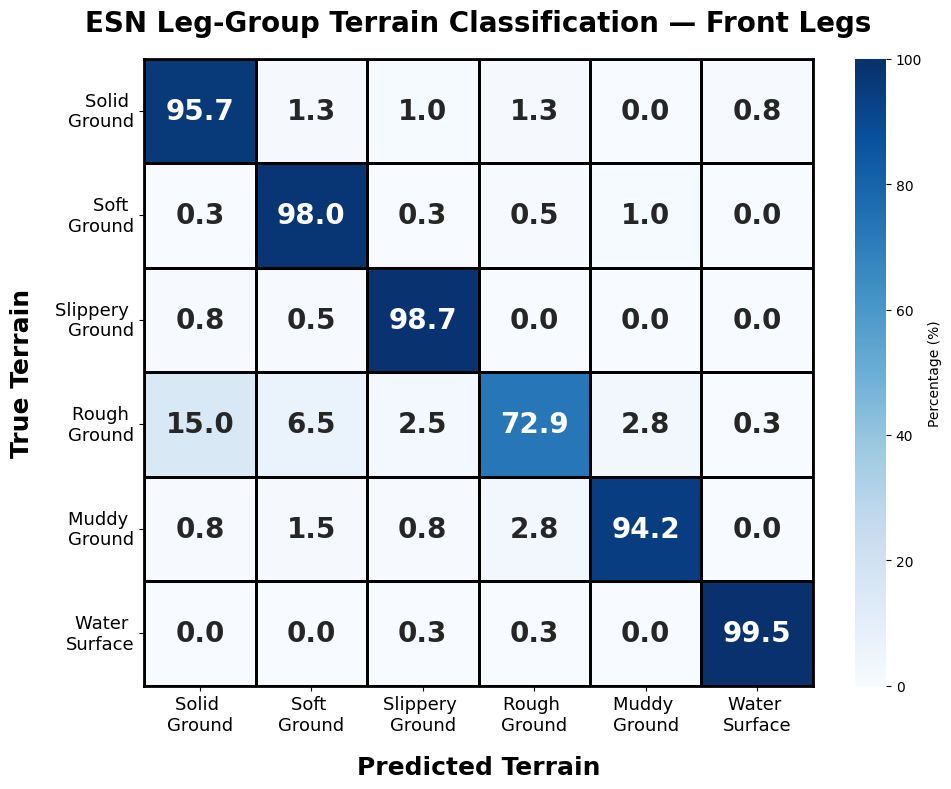

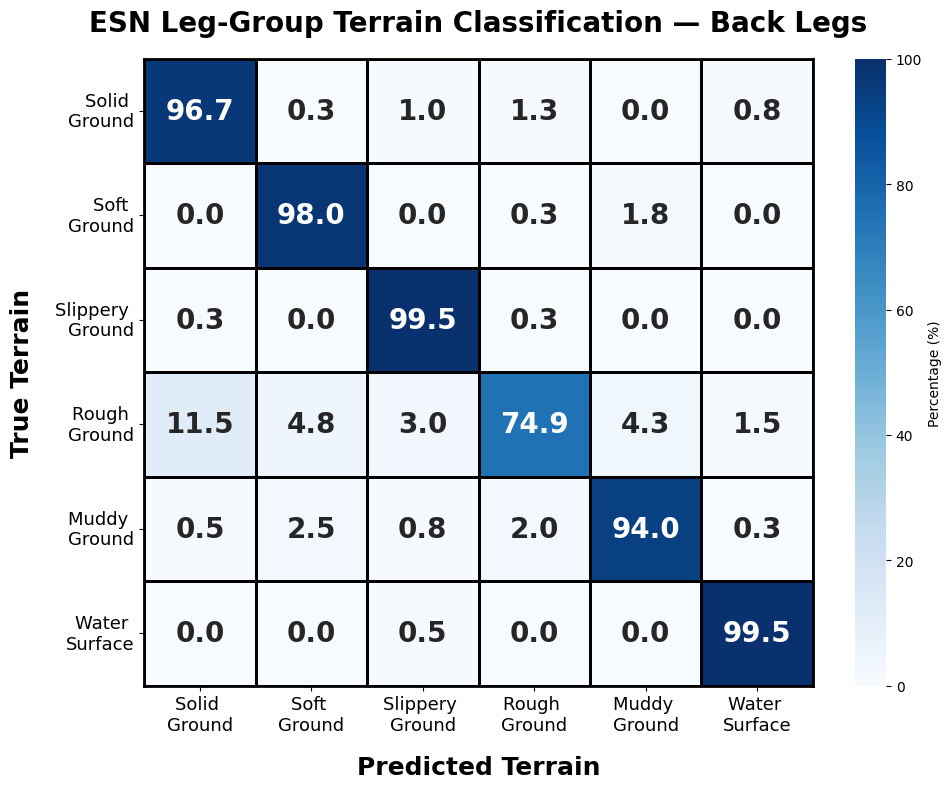

In [26]:
def plot_group_confusion_matrix(y_true, y_pred, group_label, save_path):
    custom_order = list(range(len(terrains)))
    cm = confusion_matrix(y_true, y_pred, labels=custom_order)
    terrain_names = [ID_TO_TERRAIN[i].replace('_', ' \n').title() for i in custom_order]
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm_perc, annot=True, fmt=".1f", cmap='Blues', vmax=100.0,
        linewidths=1, linecolor='black',
        annot_kws={"size": 20, "weight": "bold"},
        cbar_kws={'label': 'Percentage (%)'},
        xticklabels=terrain_names, yticklabels=terrain_names, ax=ax
    )
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_color('black')

    ax.set_title(f"ESN Leg-Group Terrain Classification — {group_label} Legs", fontsize=20, fontweight='bold', pad=20)
    ax.set_xlabel("Predicted Terrain", fontsize=18, fontweight='bold', labelpad=15)
    ax.set_ylabel("True Terrain", fontsize=18, fontweight='bold', labelpad=15)
    plt.xticks(rotation=0, fontsize=13)
    plt.yticks(rotation=0, fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

plot_group_confusion_matrix(y_test, y_pred_front, "Front", "front_group_confusion_matrix.png")
plot_group_confusion_matrix(y_test, y_pred_back, "Back", "back_group_confusion_matrix.png")

## Leg-Loss Robustness Check

In [27]:
def zero_out_leg(X, column_leg_labels, leg_to_zero):
    column_leg_labels = np.array(column_leg_labels)
    mask = column_leg_labels == leg_to_zero
    X_damaged = []
    for cycle in X:
        cycle = cycle.copy()
        cycle[:, mask] = 0.0
        X_damaged.append(cycle)
    return X_damaged

# Simulate losing the FR leg. The FRONT group loses one of its two legs
# (damaged, partial signal, mitigated by leg-dropout training above);
# the BACK group is completely unaffected - fault isolation, since it
# never saw FR data in the first place.
X_test_front_damaged = zero_out_leg(X_test_front, front_col_labels, 'FR')

y_pred_front_damaged = np.array([front_model.predict(x)[0] for x in X_test_front_damaged])
acc_front_damaged = (y_pred_front_damaged == y_test).mean() * 100

print(f"Front-group accuracy with FR leg intact:  {acc_front:.2f}%")
print(f"Front-group accuracy with FR leg lost:    {acc_front_damaged:.2f}% (expected to degrade, not collapse)")
print(f"Back-group accuracy (FR is not one of its legs, unaffected): {acc_back:.2f}%")

## Transition-Lead Check (Synthetic)

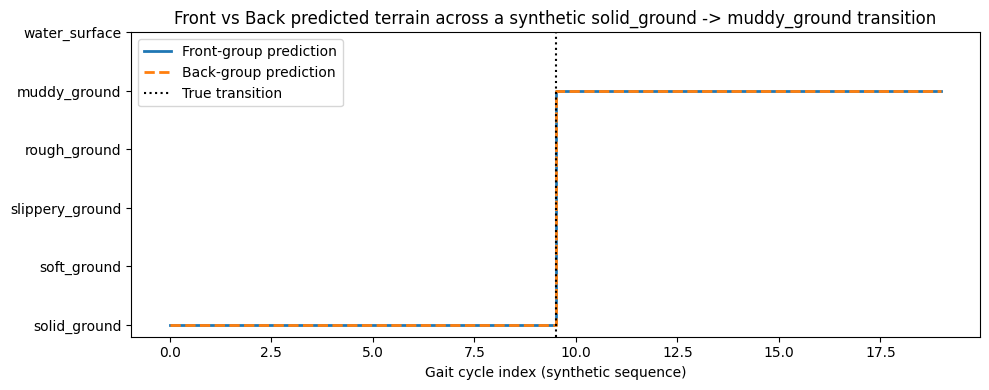

In [28]:
# NOTE: The raw continuous rosbag logs (rosbags/*.json) use different
# sensor key names (e.g. 'leg_stiffness_fb', 'foot_force_feedback') than
# the pre-segmented training dataset (e.g. 'leg_stiffness', 'foot_force')
# - post_process_dataset.ipynb bridges that naming gap and is out of
# scope for this smoke test. Also, a single rosbag episode records ONE
# terrain start-to-finish - there's no recorded mid-episode terrain
# change to measure a literal within-stride front-before-back lag.
#
# Instead, this demonstrates the transition-lead property at the
# gait-cycle level: a synthetic sequence of already-segmented test
# cycles switching from one terrain to another at a known boundary,
# classified cycle-by-cycle by both group models. It shows how many
# COMPLETE CYCLES each group needs to lock onto the new terrain after
# the switch - not the finer within-stride physical lag the full design
# is ultimately meant to exploit.

TRANSITION_FROM = 'solid_ground'
TRANSITION_TO = 'muddy_ground'
N_CYCLES_EACH_SIDE = 10

def build_transition_sequence(term_a, term_b, n_each, sensor_order, legs_to_keep):
    X_a, _, _ = flatten_datasets_leg_group({term_a: test_data[term_a]}, {term_a: 0}, sensor_order, legs_to_keep)
    X_b, _, _ = flatten_datasets_leg_group({term_b: test_data[term_b]}, {term_b: 0}, sensor_order, legs_to_keep)
    return X_a[:n_each] + X_b[:n_each]

seq_front = build_transition_sequence(TRANSITION_FROM, TRANSITION_TO, N_CYCLES_EACH_SIDE, TEST_SENSOR_CONFIG, FRONT_LEGS)
seq_back = build_transition_sequence(TRANSITION_FROM, TRANSITION_TO, N_CYCLES_EACH_SIDE, TEST_SENSOR_CONFIG, BACK_LEGS)

pred_front_seq = [front_model.predict(x)[0] for x in seq_front]
pred_back_seq = [back_model.predict(x)[0] for x in seq_back]

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(range(len(pred_front_seq)), pred_front_seq, where='mid', label='Front-group prediction', linewidth=2)
ax.step(range(len(pred_back_seq)), pred_back_seq, where='mid', label='Back-group prediction', linewidth=2, linestyle='--')
ax.axvline(N_CYCLES_EACH_SIDE - 0.5, color='black', linestyle=':', label='True transition')
ax.set_yticks(range(len(terrains)))
ax.set_yticklabels([ID_TO_TERRAIN[i] for i in range(len(terrains))])
ax.set_xlabel("Gait cycle index (synthetic sequence)")
ax.set_title(f"Front vs Back predicted terrain across a synthetic {TRANSITION_FROM} -> {TRANSITION_TO} transition")
ax.legend()
plt.tight_layout()
plt.savefig("transition_lead_check.png", dpi=200)
plt.show()

front_lag = next((i for i, p in enumerate(pred_front_seq[N_CYCLES_EACH_SIDE:]) if p == TERRAIN_LABELS[TRANSITION_TO]), None)
back_lag = next((i for i, p in enumerate(pred_back_seq[N_CYCLES_EACH_SIDE:]) if p == TERRAIN_LABELS[TRANSITION_TO]), None)
print(f"Front-group cycles to detect new terrain after transition: {front_lag}")
print(f"Back-group cycles to detect new terrain after transition:  {back_lag}")